In [1]:
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path
from functions import feature_engineering, label, create_sequences, import_csv


In [2]:
#import model and belonging objects
model_dir = Path("models/saved_lstm_autoencoder")

model = tf.keras.models.load_model(model_dir / "lstm_autoencoder.keras")

scaler = joblib.load(model_dir / "scaler.pkl")
threshold = joblib.load(model_dir / "threshold.pkl")
feature_columns = joblib.load(model_dir / "feature_columns.pkl")
window_size = joblib.load(model_dir / "window_size.pkl")

print("Modellen er lastet inn.")
print("Threshold:", threshold)
print("Window size:", window_size)
print("Antall features:", len(feature_columns))

Modellen er lastet inn.
Threshold: 0.10404626509857504
Window size: 30
Antall features: 18


In [3]:
#Define CSV's to import and use for testing

attack_csv = [
    "Attack-0.csv",
    "Attack-1.csv"
]

attack_log = [
    "attack-log-02-01-2023.csv"
]

csv_folder = Path.cwd()/"CSV files"

In [4]:
#importing csv's
attack_df = import_csv(attack_csv, csv_folder)
attack_log_df = import_csv(attack_log, csv_folder)

Reading: C:\Users\Even_\OneDrive\Master\Dataset\Jupyter\CSV files\Attack-0.csv
Reading: C:\Users\Even_\OneDrive\Master\Dataset\Jupyter\CSV files\Attack-1.csv
Reading: C:\Users\Even_\OneDrive\Master\Dataset\Jupyter\CSV files\attack-log-02-01-2023.csv


In [5]:
#labeling attack_df based on time from attack_log
attack_df=label(attack_df,attack_log_df)

In [6]:
#Split data
y_eval = y_eval = attack_df["Label"].copy()
X_eval = feature_engineering(attack_df.drop(columns=["Label"]))

In [7]:
#scale data
X_eval_scaled = scaler.transform(X_eval)

In [8]:
#create sequences
X_seq,y_seq = create_sequences(X_eval_scaled,window_size, labels=y_eval)

In [9]:
#Reconstruct sequences
X_pred = model.predict(X_seq)


# Calculate reconstruction errors
reconstruction_error = np.mean(
    np.mean((X_seq - X_pred) ** 2, axis=2),
    axis=1
)

print("Reconstruction error:")
print(pd.Series(reconstruction_error).describe())


8814/8814 ━━━━━━━━━━━━━━━━━━━━ 120s 14ms/step
Reconstruction error:
count    282048.000000
mean          5.532446
std          12.247775
min           0.000986
25%           0.002843
50%           0.005819
75%           0.024431
max          52.544780
dtype: float64


In [24]:
# Predict anomaly based on treshold
# 0 = normal
# 1 = anomaly

y_pred = (reconstruction_error > (threshold)).astype(int)

print("\nPredicted labels:")
print(pd.Series(y_pred).value_counts())

print("\nTrue labels:")
print(pd.Series(y_seq).value_counts())


Predicted labels:
0    215911
1     66137
Name: count, dtype: int64

True labels:
0    214766
1     67282
Name: count, dtype: int64


In [28]:
#Print results
print("\nConfusion matrix:")
print(confusion_matrix(y_seq, y_pred))

print("\nClassification report:")
print(classification_report(
    y_seq,
    y_pred,
    target_names=["Normal", "Anomaly"],
    zero_division=0
))

print("Accuracy:", accuracy_score(y_seq, y_pred))
print("Precision:", precision_score(y_seq, y_pred, zero_division=0))
print("Recall:", recall_score(y_seq, y_pred, zero_division=0))
print("F1-score:", f1_score(y_seq, y_pred, zero_division=0))



Confusion matrix:
[[214761      5]
 [  1150  66132]]

Classification report:
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00    214766
     Anomaly       1.00      0.98      0.99     67282

    accuracy                           1.00    282048
   macro avg       1.00      0.99      0.99    282048
weighted avg       1.00      1.00      1.00    282048

Accuracy: 0.9959049523485364
Precision: 0.9999243993528585
Recall: 0.982907761362623
F1-score: 0.9913430620826119


In [26]:
#Create results dataframe

results_df = pd.DataFrame({
    "true_label": y_seq,
    "predicted_label": y_pred,
    "reconstruction_error": reconstruction_error
})

results_df["correct"] = results_df["true_label"] == results_df["predicted_label"]

print("\nResultater:")
print(results_df.head())
print(results_df["correct"].value_counts())


Resultater:
   true_label  predicted_label  reconstruction_error  correct
0           0                0              0.053010     True
1           0                0              0.025652     True
2           0                0              0.030677     True
3           0                0              0.039189     True
4           0                0              0.056095     True
correct
True     280893
False      1155
Name: count, dtype: int64


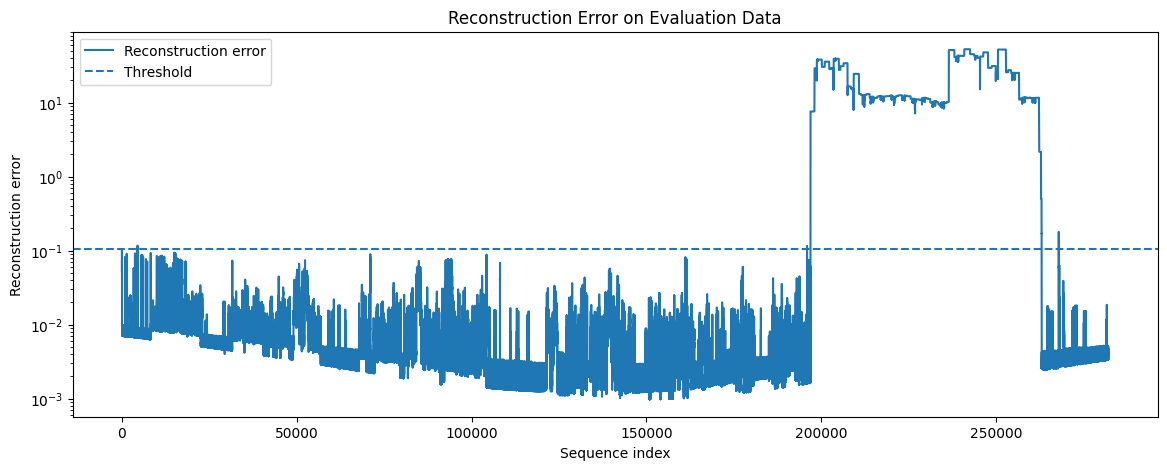

In [22]:
# Plot reconstruction error

plt.figure(figsize=(14, 5))
plt.plot(results_df["reconstruction_error"], label="Reconstruction error")
plt.axhline((threshold), linestyle="--", label="Threshold")
plt.title("Reconstruction Error on Evaluation Data")
plt.xlabel("Sequence index")
plt.ylabel("Reconstruction error")
plt.legend()
plt.yscale("log")
plt.show()


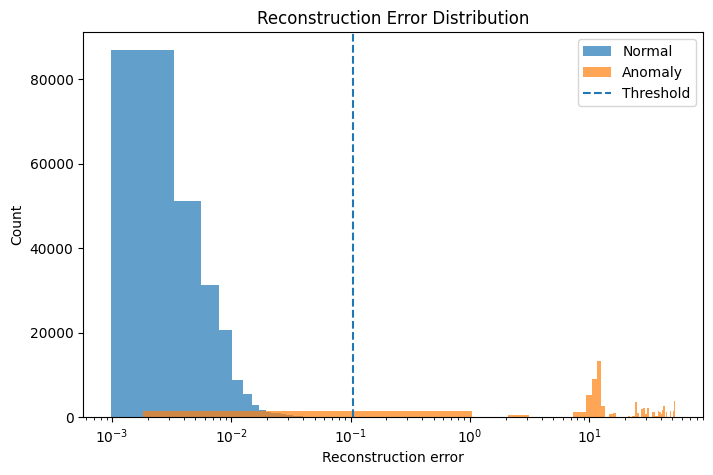

In [23]:
# Plot reconstruction error distribution

plt.figure(figsize=(8, 5))

plt.hist(
    results_df.loc[results_df["true_label"] == 0, "reconstruction_error"],
    bins=50,
    alpha=0.7,
    label="Normal"
)

plt.hist(
    results_df.loc[results_df["true_label"] == 1, "reconstruction_error"],
    bins=50,
    alpha=0.7,
    label="Anomaly"
)

plt.axvline((threshold), linestyle="--", label="Threshold")
plt.title("Reconstruction Error Distribution")
plt.xlabel("Reconstruction error")
plt.ylabel("Count")
plt.legend()
plt.xscale("log")
plt.show()

In [27]:
# Classify each prediction
conditions = [
    (results_df["true_label"] == 1) & (results_df["predicted_label"] == 1),  # TP
    (results_df["true_label"] == 0) & (results_df["predicted_label"] == 0),  # TN
    (results_df["true_label"] == 0) & (results_df["predicted_label"] == 1),  # FP
    (results_df["true_label"] == 1) & (results_df["predicted_label"] == 0),  # FN
]

choices = ["TP", "TN", "FP", "FN"]

results_df["classification"] = np.select(
    conditions,
    choices,
    default="Unknown"
)

# Add sequence index as time axis
results_df["sequence_index"] = results_df.index

print(results_df["classification"].value_counts())

classification
TN    214761
TP     66132
FN      1150
FP         5
Name: count, dtype: int64


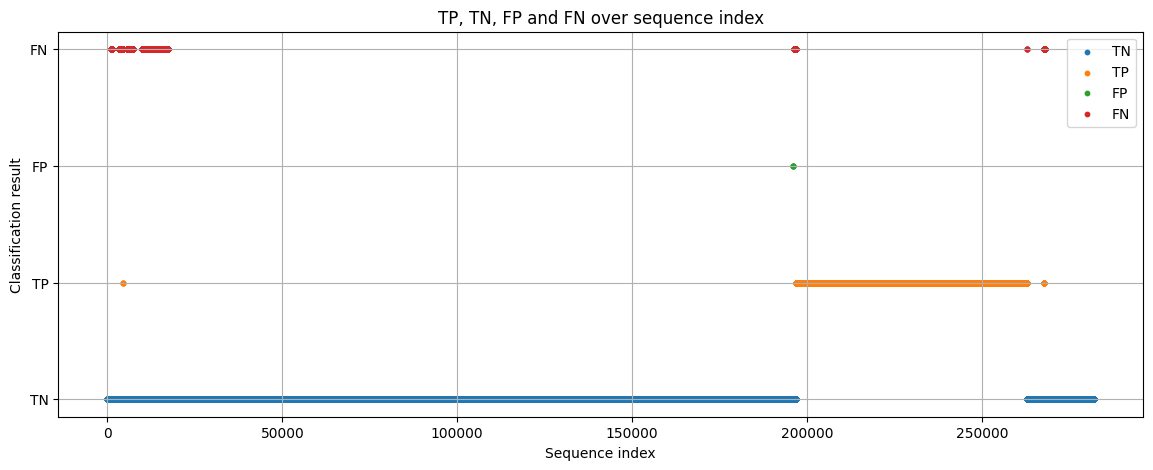

In [29]:
#Plot results over index
plt.figure(figsize=(14, 5))

classification_y = {
    "TN": 0,
    "TP": 1,
    "FP": 2,
    "FN": 3
}

results_df["plot_y"] = results_df["classification"].map(classification_y)

for label in ["TN", "TP", "FP", "FN"]:
    subset = results_df[results_df["classification"] == label]
    plt.scatter(
        subset["sequence_index"],
        subset["plot_y"],
        label=label,
        s=10
    )

plt.yticks(
    [0, 1, 2, 3],
    ["TN", "TP", "FP", "FN"]
)

plt.xlabel("Sequence index")
plt.ylabel("Classification result")
plt.title("TP, TN, FP and FN over sequence index")
plt.legend()
plt.grid(True)
plt.show()